In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import joblib
import shap
import pandas as pd

# plotly
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.15f' % x)  # Exibe 5 casas decimais

import numpy as np

import warnings
warnings.filterwarnings('ignore')


In [2]:
gdf = gpd.read_file('../../dataset/shp/final_version_no_missing_values.shp')
gdf['log_population'] = np.log(gdf['population'].replace(0, np.nan))
gdf['log_prim_hosp'] = np.log(gdf['prim_hosp'].replace(0, np.nan))
gdf['log_inp_hosp'] = np.log(gdf['inp_hosp'].replace(0, np.nan))
gdf['log_est_dens'] = np.log(gdf['est_dens'].replace(0, np.nan))

In [211]:
gdf

,CD_FCU,NM_FCU,CD_UF,NM_UF,SIGLA_UF,CD_MUN,NM_MUN,distance,dist_km,dist_norm,area,hh_density,age_idx,median_age,sex_ratio,literate,race_wht,race_blk,race_ylw,race_brn,race_ind,race_unk,depriv_idx,priv_hh,coll_hh,hh_type_1,hh_type_2,hh_type_3,hh_type_4,hh_type_5,hh_type_6,sanit_1,sanit_2,sanit_3,sanit_4,sanit_5,sanit_6,sanit_7,no_bath,excl_bath,shrd_bath,toilet,no_toilet,wtr_pipe,wtr_semi,no_wtr_pip,wtr_dist,wtr_deep,wtr_shal,wtr_spring,wtr_truck,wtr_rain,wtr_river,wtr_oth,wtr_area,veg_area,risk,slope_10,slope_20,slope_30,slope_30p,hand_6p,hand_3_6,hand_0_3,SO2,CO,O3,NO2,waste_coll,demo_dens,est_dens,est_edu,est_health,est_relig,est_agri,est_other,est_const,intra_veg,prim_hosp,inp_hosp,wtr_idx,sanit_idx,liv_a_idx,hh_idx,cluster,population,area_km2,density_km,geometry,log_population,log_prim_hosp,log_inp_hosp,log_est_dens
0,35503080069,Jardim Miliunas,35,São Paulo,SP,3550308,São Paulo,23646.846826038814470,23.646846826038814,0.533158552343469,1521.201999999999998,2.956632653061225,44.020000000000003,29.000000000000000,99.000000000000000,92.890000000000001,32.609999999999999,17.340000000000000,0.000000000000000,50.039999999999999,0.000000000000000,0.000000000000000,0.593881394151810,100.000000000000000,0.000000000000000,0.318900000000000,0.002600000000000,0.000000000000000,0.678600000000000,0.000000000000000,0.000000000000000,0.206600000000000,0.000000000000000,0.030600000000000,0.000000000000000,0.000000000000000,0.762800000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.994900000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.005100000000000,0.000000000000000,0.000000000000000,0.000000000000000,50.965558831959356,49.034441168040658,0.000000000000000,0.000000000000000,35.578202056669660,26.962626321230797,37.459171622099561,0.000226338812134,0.032435898459901,0.117353676384719,0.000138925792410,98.719999999999999,45062.209999999999127,884.615384615384642,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,100.000000000000000,100.000000000000000,0.000000000000000,752.192509434099634,2071.724078601533165,0.997450127493625,0.451028037383178,0.681207545029720,0.321535692861428,1.000000000000000,1159,0.026000000000000,45062.209999999999127,"POLYGON ((-5162009.388 -2692597.734, -5162042....",7.055312843339752,6.622992287776203,7.636136427813800,6.785152956889805
1,42024040016,Rua Araranguá,42,Santa Catarina,SC,4202404,Blumenau,2544.012189292799121,2.544012189292799,0.080353569412576,518.619000000000028,2.809917355371901,60.270000000000003,34.000000000000000,102.000000000000000,96.629999999999995,79.709999999999994,4.120000000000000,0.000000000000000,16.180000000000000,0.000000000000000,0.000000000000000,-1.339049333599375,100.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.958700000000000,0.000000000000000,0.033100000000000,0.000000000000000,0.008300000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,3.783948041683024,100.000000000000000,0.120335888401926,9.787379757137918,12.635362314477181,77.456922039982985,88.808712208672446,6.551667421570913,4.639620369756640,0.000128408715662,0.030195952437025,0.119900281982149,0.000063380103705,100.000000000000000,2916.000000000000000,8.547008547008547,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,100.000000000000000,0.000000000000000,886.945621266084572,281.660799669791857,1167.193154171149445,1.000000000000000,0.978808411214953,0.872972435449063,0.999800039992001,0.00000

In [210]:
gdf.drop(columns="geometry").to_csv("../../dataset/csv/final_version_no_missing_values.csv", index=False)

In [218]:
gdf2 = gpd.read_file("../../dataset/shp/final_version.shp")
df = gdf2.drop(columns="geometry")
df

,CD_FCU,NM_FCU,CD_UF,NM_UF,SIGLA_UF,CD_MUN,NM_MUN,distance,dist_km,dist_norm,area,hh_density,age_idx,median_age,sex_ratio,literate,race_wht,race_blk,race_ylw,race_brn,race_ind,race_unk,depriv_idx,priv_hh,coll_hh,hh_type_1,hh_type_2,hh_type_3,hh_type_4,hh_type_5,hh_type_6,sanit_1,sanit_2,sanit_3,sanit_4,sanit_5,sanit_6,sanit_7,no_bath,excl_bath,shrd_bath,toilet,no_toilet,wtr_pipe,wtr_semi,no_wtr_pip,wtr_dist,wtr_deep,wtr_shal,wtr_spring,wtr_truck,wtr_rain,wtr_river,wtr_oth,wtr_area,veg_area,risk,slope_10,slope_20,slope_30,slope_30p,hand_6p,hand_3_6,hand_0_3,SO2,CO,O3,NO2,waste_coll,demo_dens,est_dens,est_edu,est_health,est_relig,est_agri,est_other,est_const,intra_veg,prim_hosp,inp_hosp,wtr_idx,sanit_idx,liv_a_idx,hh_idx,cluster,population,area_km2,density_km
0,35503080069,Jardim Miliunas,35,São Paulo,SP,3550308,São Paulo,23646.846826038814470,23.646846826038814,0.533158552343469,1521.201999999999998,2.956632653061225,44.020000000000003,29.000000000000000,99.000000000000000,92.890000000000001,32.609999999999999,17.340000000000000,0.000000000000000,50.039999999999999,0.000000000000000,0.000000000000000,0.593881394151810,100.000000000000000,0.000000000000000,0.318900000000000,0.002600000000000,0.000000000000000,0.678600000000000,0.000000000000000,0.000000000000000,0.206600000000000,0.000000000000000,0.030600000000000,0.000000000000000,0.000000000000000,0.762800000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.994900000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.005100000000000,0.000000000000000,0.000000000000000,0.000000000000000,50.965558831959356,49.034441168040658,0.000000000000000,0.000000000000000,35.578202056669660,26.962626321230797,37.459171622099561,0.000226338812134,0.032435898459901,0.117353676384719,0.000138925792410,98.719999999999999,45062.209999999999127,884.615384615384642,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,100.000000000000000,100.000000000000000,0.000000000000000,752.192509434099634,2071.724078601533165,0.997450127493625,0.451028037383178,0.681207545029720,0.321535692861428,1.000000000000000,1159,0.026000000000000,45062.209999999999127
1,42024040016,Rua Araranguá,42,Santa Catarina,SC,4202404,Blumenau,2544.012189292799121,2.544012189292799,0.080353569412576,518.619000000000028,2.809917355371901,60.270000000000003,34.000000000000000,102.000000000000000,96.629999999999995,79.709999999999994,4.120000000000000,0.000000000000000,16.180000000000000,0.000000000000000,0.000000000000000,-1.339049333599375,100.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.958700000000000,0.000000000000000,0.033100000000000,0.000000000000000,0.008300000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,3.783948041683024,100.000000000000000,0.120335888401926,9.787379757137918,12.635362314477181,77.456922039982985,88.808712208672446,6.551667421570913,4.639620369756640,0.000128408715662,0.030195952437025,0.119900281982149,0.000063380103705,100.000000000000000,2916.000000000000000,8.547008547008547,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,100.000000000000000,0.000000000000000,886.945621266084572,281.660799669791857,1167.193154171149445,1.000000000000000,0.978808411214953,0.872972435449063,0.999800039992001,0.000000000000000,340,0.117000000000000,2916.000000000000000
2,33045570554,Tiqui,33,Rio de Janeiro,RJ,3304557,Rio de Janeiro,28454.700967727036186,28.454700967727035,0.507650945554618,1200.328999

In [220]:
region_map = {
    'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}
df["Regiao"] = df["SIGLA_UF"].map(region_map)

In [221]:
# Média de sanit_1 por região
if "sanit_1" in df.columns and "Regiao" in df.columns:
    media_sanit_1_por_regiao = df.groupby("Regiao")["sanit_1"].mean()
    display(media_sanit_1_por_regiao)
else:
    print("Coluna 'sanit_1' ou 'Regiao' não encontrada no DataFrame.")


Regiao
Centro-Oeste   0.247158745874587
Nordeste       0.381555693144065
Norte          0.149773365785814
Sudeste        0.686008164283339
Sul            0.572389593114241
Name: sanit_1, dtype: float64

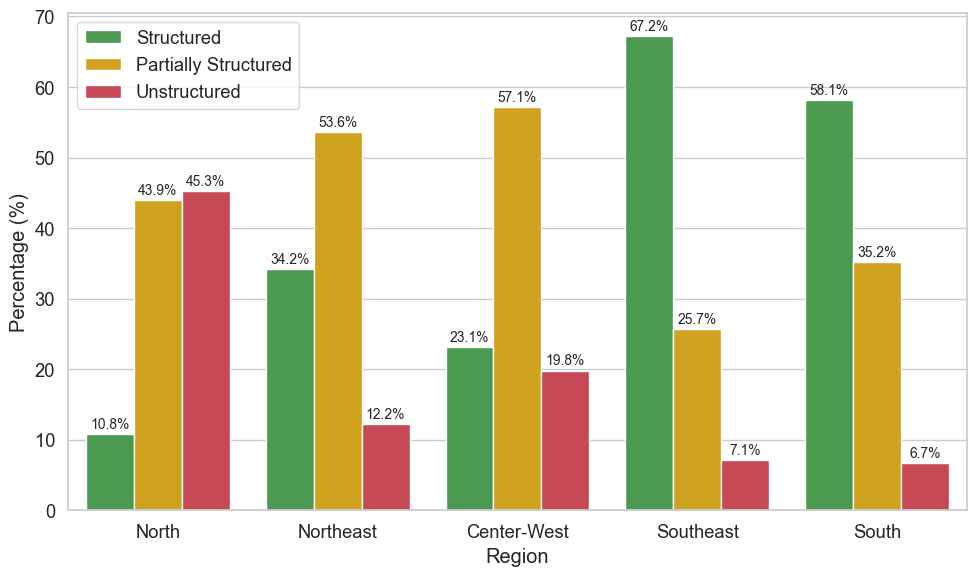

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map Portuguese region names to English
region_pt_to_en = {
    "Norte": "North",
    "Nordeste": "Northeast",
    "Centro-Oeste": "Center-West",
    "Sudeste": "Southeast",
    "Sul": "South"
}
regions_pt = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
regions_en = [region_pt_to_en[r] for r in regions_pt]
colors = ['#3fa745', '#ecb102', '#dc3444']
cluster_labels = ['Structured', 'Partially Structured', 'Unstructured']

# Certifique-se de que os nomes das colunas estão corretos: "Regiao" e "cluster"
if "Regiao" in df.columns and "cluster" in df.columns:
    # Mapeia o nome das regiões para inglês para o plot
    df_plot = df.copy()
    df_plot['Region_EN'] = df_plot['Regiao'].map(region_pt_to_en)

    # Calcula o total de registros por região (para porcentagem)
    total_por_regiao = df_plot.groupby('Region_EN').size().reset_index(name='total_regiao')
    # Total por região e cluster
    total_por_regiao_cluster = df_plot.groupby(['Region_EN', 'cluster']).size().reset_index(name='total')
    # Junta as infos
    total_por_regiao_cluster = total_por_regiao_cluster.merge(total_por_regiao, on='Region_EN')
    # Calcula a porcentagem de cada cluster em relação ao total da região
    total_por_regiao_cluster['percent'] = 100 * total_por_regiao_cluster['total'] / total_por_regiao_cluster['total_regiao']

    # Ordena os dados de acordo com a ordem desejada das regiões em inglês
    total_por_regiao_cluster['Region_EN'] = pd.Categorical(
        total_por_regiao_cluster['Region_EN'], categories=regions_en, ordered=True
    )
    total_por_regiao_cluster = total_por_regiao_cluster.sort_values(['Region_EN', 'cluster'])

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=total_por_regiao_cluster, 
        x='Region_EN', 
        y='percent', 
        hue='cluster',
        palette=colors,
        order=regions_en  # Garante a ordem correta em inglês
    )
    plt.xlabel('Region')
    plt.ylabel('Percentage (%)')

    # Ajusta legenda para os labels desejados
    handles, _ = ax.get_legend_handles_labels()
    plt.legend(handles=handles, labels=cluster_labels)

    # Adiciona porcentagem sobre cada barra com fonte um pouco menor
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.1f%%',  
            label_type='edge', 
            padding=2,
            fontsize=10 # fonte menor para os valores acima das barras
        )

    plt.tight_layout()
    plt.show()
else:
    print("Coluna 'Regiao' ou 'cluster' não encontrada no DataFrame.")


In [238]:
# Calcula a somatória de registros por cluster e por região, com porcentagem e número absoluto
if "Regiao" in df.columns and "cluster" in df.columns:
    # Número absoluto de registros por cluster e região
    abs_counts = df.groupby(['Regiao', 'cluster']).size().reset_index(name='absolute_count')
    # Total de registros por região
    total_region = df.groupby('Regiao').size().reset_index(name='region_total')
    # Junta para calcular apenas a porcentagem (não inclui region_total no resultado)
    abs_counts = abs_counts.merge(total_region, on='Regiao')
    abs_counts['percentage'] = 100 * abs_counts['absolute_count'] / abs_counts['region_total']
    abs_counts = abs_counts.drop(columns=['region_total'])
    # Ordena pelas regiões na ordem padrão, se possível
    if set(regions).issubset(set(abs_counts['Regiao'].unique())):
        abs_counts['Regiao'] = pd.Categorical(abs_counts['Regiao'], categories=regions, ordered=True)
        abs_counts = abs_counts.sort_values('Regiao')
    print(abs_counts)
else:
    print("Coluna 'Regiao' ou 'cluster' não encontrada no DataFrame.")



          Regiao           cluster  absolute_count         percentage
6          Norte 0.000000000000000             155 10.778859527121002
7          Norte 1.000000000000000             632 43.949930458970790
8          Norte 2.000000000000000             651 45.271210013908203
3       Nordeste 0.000000000000000            1132 34.189066747206283
4       Nordeste 1.000000000000000            1775 53.609181516158259
5       Nordeste 2.000000000000000             404 12.201751736635458
0   Centro-Oeste 0.000000000000000              70 23.102310231023104
1   Centro-Oeste 1.000000000000000             173 57.095709570957098
2   Centro-Oeste 2.000000000000000              60 19.801980198019802
9        Sudeste 0.000000000000000            4039 67.159960093116069
10       Sudeste 1.000000000000000            1546 25.706684403059526
11       Sudeste 2.000000000000000             429  7.133355503824410
12           Sul 0.000000000000000             743 58.137715179968701
13           Sul 1.0

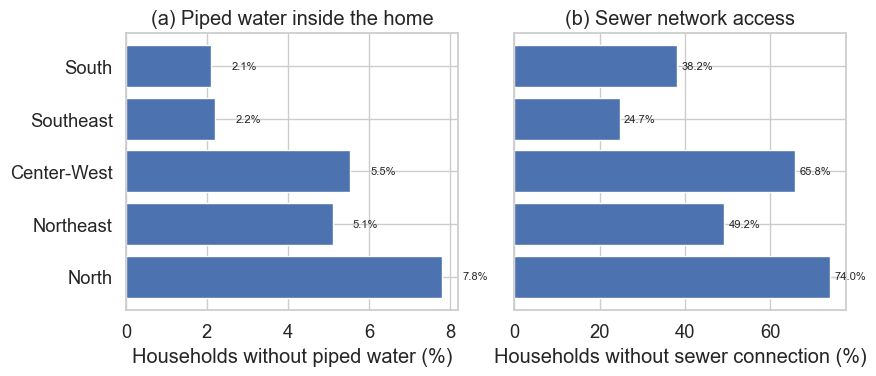

In [247]:
import matplotlib.pyplot as plt
import numpy as np

regions = ["North", "Northeast", "Center-West", "Southeast", "South"]

no_piped = [7.8, 5.1, 5.54, 2.21, 2.10]   # %
no_sewer = [74.0, 49.17, 65.78, 24.71, 38.22]  # %

y = np.arange(len(regions))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# (a) Water
ax = axes[0]
ax.barh(y, no_piped)
ax.set_yticks(y)
ax.set_yticklabels(regions)
ax.invert_yaxis()
ax.set_xlabel("Households without piped water (%)")
ax.set_title("(a) Piped water inside the home")
for i, v in enumerate(no_piped):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

# (b) Sanitation
ax = axes[1]
ax.barh(y, no_sewer)
ax.invert_yaxis()
ax.set_xlabel("Households without sewer connection (%)")
ax.set_title("(b) Sewer network access")
for i, v in enumerate(no_sewer):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

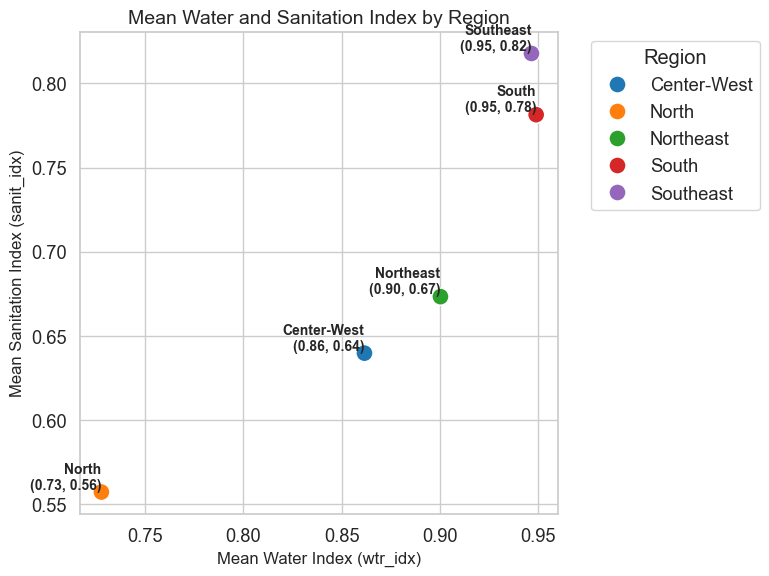

In [251]:
import seaborn as sns

# Find region column
region_col = None
possible_cols = ["Regiao", "region", "regiao", "NM_REGIAO"]
for col in gdf.columns:
    if col in possible_cols:
        region_col = col
        break

if region_col is None:
    # Map region from UF column if not already present
    if "CD_UF" in gdf.columns:
        uf_to_region = {
            "RO": "North", "AC": "North", "AM": "North", "RR": "North", "PA": "North", "AP": "North", "TO": "North", "11": "North", "12": "North", "13": "North", "14": "North", "15": "North", "16": "North", "17": "North",
            "MA": "Northeast", "PI": "Northeast", "CE": "Northeast", "RN": "Northeast", "PB": "Northeast", "PE": "Northeast", "AL": "Northeast", "SE": "Northeast", "BA": "Northeast",
            "21": "Northeast", "22": "Northeast", "23": "Northeast", "24": "Northeast", "25": "Northeast", "26": "Northeast", "27": "Northeast", "28": "Northeast", "29": "Northeast",
            "MG": "Southeast", "ES": "Southeast", "RJ": "Southeast", "SP": "Southeast", "31": "Southeast", "32": "Southeast", "33": "Southeast", "35": "Southeast",
            "PR": "South", "SC": "South", "RS": "South", "41": "South", "42": "South", "43": "South",
            "MS": "Center-West", "MT": "Center-West", "GO": "Center-West", "DF": "Center-West", "50": "Center-West", "51": "Center-West", "52": "Center-West", "53": "Center-West"
        }
        uf_vals = gdf['CD_UF'].astype(str)
        gdf["_region_temp"] = uf_vals.map(uf_to_region)
        region_col = "_region_temp"
    else:
        raise ValueError("No region column found in gdf.")

# Group by region and calculate means
means = gdf.groupby(region_col, dropna=False)[["wtr_idx", "sanit_idx"]].mean().reset_index()
means = means.dropna(subset=["wtr_idx", "sanit_idx", region_col])

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=means,
    x='wtr_idx',
    y='sanit_idx',
    hue=region_col,
    palette='tab10',
    s=150,
    legend="full"
)

for i, row in means.iterrows():
    # Label with region (bold), and value at each point
    label = f"{row[region_col]}\n({row['wtr_idx']:.2f}, {row['sanit_idx']:.2f})"
    plt.text(row["wtr_idx"], row["sanit_idx"], label, fontsize=10, weight="bold", va="bottom", ha="right")

plt.title("Mean Water and Sanitation Index by Region", fontsize=14)
plt.xlabel("Mean Water Index (wtr_idx)", fontsize=12)
plt.ylabel("Mean Sanitation Index (sanit_idx)", fontsize=12)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


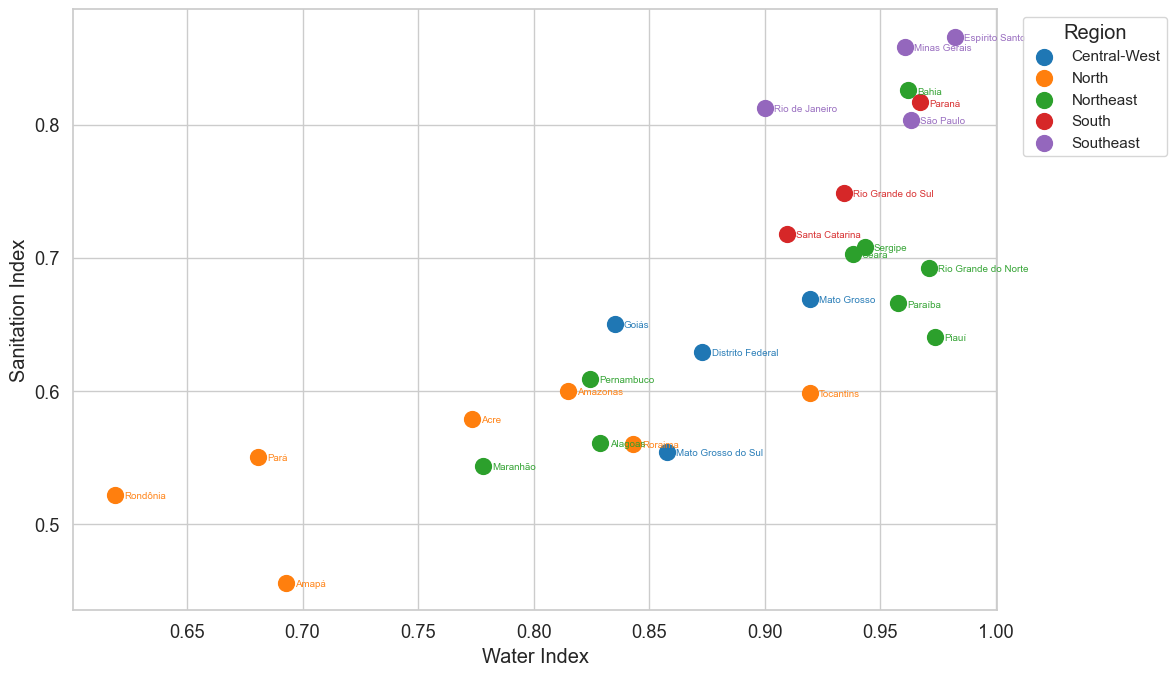

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determina a coluna da região
if "region" in gdf.columns:
    region_col_plot = "region"
elif "_region_temp" in gdf.columns:
    region_col_plot = "_region_temp"
else:
    uf_to_region = {
        "RO": "North", "AC": "North", "AM": "North", "RR": "North", "PA": "North", "AP": "North", "TO": "North", "11": "North", "12": "North", "13": "North", "14": "North", "15": "North", "16": "North", "17": "North",
        "MA": "Northeast", "PI": "Northeast", "CE": "Northeast", "RN": "Northeast", "PB": "Northeast", "PE": "Northeast", "AL": "Northeast", "SE": "Northeast", "BA": "Northeast",
        "21": "Northeast", "22": "Northeast", "23": "Northeast", "24": "Northeast", "25": "Northeast", "26": "Northeast", "27": "Northeast", "28": "Northeast", "29": "Northeast",
        "MG": "Southeast", "ES": "Southeast", "RJ": "Southeast", "SP": "Southeast", "31": "Southeast", "32": "Southeast", "33": "Southeast", "35": "Southeast",
        "PR": "South", "SC": "South", "RS": "South", "41": "South", "42": "South", "43": "South",
        "MS": "Center-West", "MT": "Center-West", "GO": "Center-West", "DF": "Center-West", "50": "Center-West", "51": "Center-West", "52": "Center-West", "53": "Center-West"
    }
    gdf["_region_temp"] = gdf["CD_UF"].astype(str).map(uf_to_region)
    region_col_plot = "_region_temp"

# Agrupa por estado (CD_UF)
grouped = gdf.groupby("CD_UF").agg(
    sanit_idx=("sanit_idx", "mean"),
    wtr_idx=("wtr_idx", "mean")
).reset_index()

# Adiciona coluna de região para o agrupado
if "region" in gdf.columns:
    states_to_region = gdf.set_index("CD_UF")["region"].to_dict()
elif "_region_temp" in gdf.columns:
    states_to_region = gdf.set_index("CD_UF")["_region_temp"].to_dict()
else:
    states_to_region = {uf: uf_to_region.get(str(uf), None) for uf in grouped["CD_UF"]}

grouped["region"] = grouped["CD_UF"].astype(str).map(states_to_region)

# Adiciona o nome do estado (NM_UF) para cada código UF, para plotar
if "NM_UF" in gdf.columns:
    cd_uf_to_nm_uf = gdf.drop_duplicates(subset=["CD_UF"])[["CD_UF","NM_UF"]].set_index("CD_UF")["NM_UF"].to_dict()
    grouped["nm_uf"] = grouped["CD_UF"].map(cd_uf_to_nm_uf)
else:
    grouped["nm_uf"] = grouped["CD_UF"].astype(str)

# Remove estados sem região informada ou valores faltando
grouped = grouped.dropna(subset=["region", "sanit_idx", "wtr_idx"])

# Lista única de regiões
region_list = sorted(grouped["region"].unique())

# Paleta de cores para as regiões
palette = sns.color_palette('tab10', len(region_list))
region_color_map = {r: palette[i % len(palette)] for i, r in enumerate(region_list)}

plt.figure(figsize=(12, 7))

for region in region_list:
    df_region = grouped[grouped["region"] == region]
    plt.scatter(
        df_region["wtr_idx"],
        df_region["sanit_idx"],
        color=region_color_map[region],
        label=region,
        s=130
        # edgecolor removido
    )
    # Adiciona o nome do estado (NM_UF) ACIMA de cada ponto, fonte bem pequena
    for _, row in df_region.iterrows():
        plt.text(
            row["wtr_idx"] + 0.004,
            row["sanit_idx"] - 0.004,  # desloca o texto um pouco para cima do ponto
            str(row["nm_uf"]),
            fontsize=7, ha='left', va='bottom', color=region_color_map[region], alpha=0.95
        )

plt.xlabel("Water Index")
plt.ylabel("Sanitation Index")


plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=11
)

plt.tight_layout()
plt.show()


In [356]:
import plotly.graph_objects as go

# --------- Sankey: proporção por região -> cluster ---------

# Criar coluna 'region' em gdf, igual ao que foi feito em grouped anteriormente
# Supondo que você já tem os mapeamentos 'uf_to_region' disponíveis
if "region" not in gdf.columns:
    states_to_region = {uf: uf_to_region.get(str(uf), None) for uf in gdf["CD_UF"]}
    gdf["region"] = gdf["CD_UF"].astype(str).map(states_to_region)

# Prosseguir normalmente
sankey_df = gdf.dropna(subset=["region", "cluster"]).copy()
sankey_df["cluster"] = sankey_df["cluster"].astype(str)
sankey_df["region"] = sankey_df["region"].astype(str)

regions = sorted(sankey_df["region"].unique())
clusters = sorted(sankey_df["cluster"].unique())

region_to_idx = {r: i for i, r in enumerate(regions)}
cluster_to_idx = {c: i + len(regions) for i, c in enumerate(clusters)}

counts = sankey_df.groupby(["region", "cluster"]).size().reset_index(name="count")
counts = counts[counts["count"] > 0]

sources = counts["region"].map(region_to_idx).tolist()
targets = counts["cluster"].map(cluster_to_idx).tolist()
values = counts["count"].tolist()

labels = regions + [f"Cluster {c}" for c in clusters]

fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 20,
        thickness = 24,
        line = dict(color = "black", width = 0.6),
        label = labels,
        color = ["#5292a7"]*len(regions) + ["#3fa745", "#fab800", "#dc3444"][:len(clusters)]
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = "rgba(120,120,120,0.3)"
    )
)])

fig.update_layout(title="Transição das proporções: Região → Cluster", font_size=14, height=450, width=750)
fig.show()



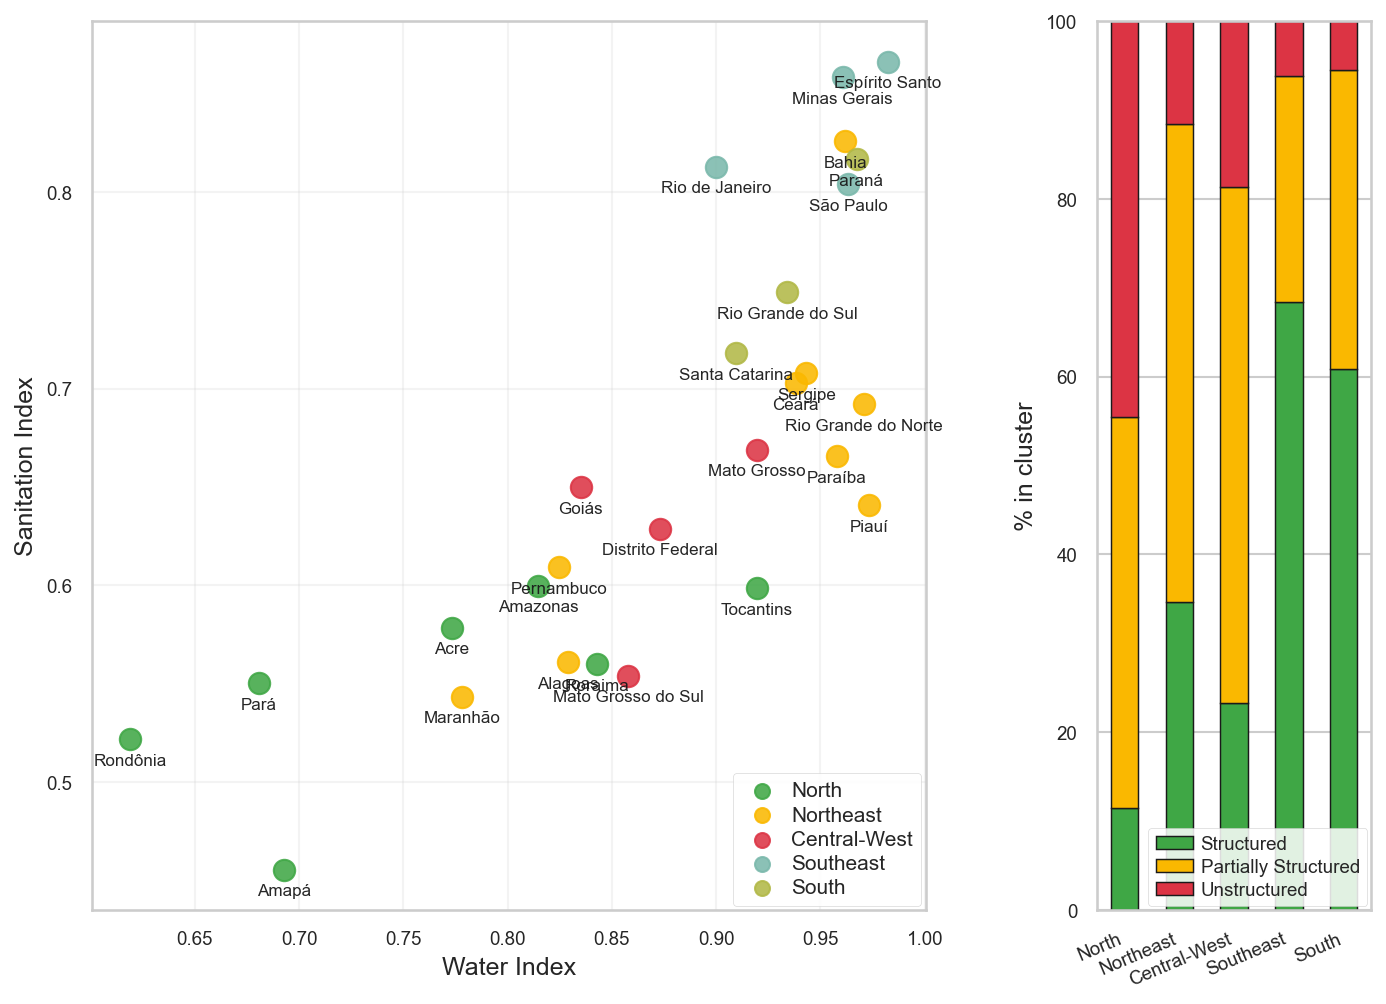

In [396]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- Ensure consistent region names in English ----
region_map_to_en = {
    "North": "North",
    "Norte": "North",
    "Northeast": "Northeast",
    "Nordeste": "Northeast",
    "Southeast": "Southeast",
    "Sudeste": "Southeast",
    "South": "South",
    "Sul": "South",
    "Center-West": "Central-West",
    "Centro Oeste": "Central-West",
    "Centro-Oeste": "Central-West",
    "Central-West": "Central-West"
}
gdf["region"] = gdf["region"].replace(region_map_to_en)

import plotly.graph_objects as go

regions_order = ["North", "Northeast", "Central-West", "Southeast", "South"]

# Paleta de cores das regiões para o scatter, aproximada das cores dos clusters
region_palette = {
    "North": "#3fa745",         # Structured (verde) 
    "Northeast": "#fab800",     # Partially Structured (amarelo)
    "Central-West": "#dc3444",  # Unstructured (vermelho)
    "Southeast": "#7ab8ab",     # similar ao azul claro do boxplot original
    "South": "#b1b846",         # um tom verde-amarelado não usado ainda
}

# Cores dos clusters (barplot)
colors_cb = ["#3fa745", "#fab800", "#dc3444"]
cluster_label_map = {
    "0.0": "Structured",
    "1.0": "Partially Structured",
    "2.0": "Unstructured",
    0.0: "Structured",
    1.0: "Partially Structured",
    2.0: "Unstructured",
    0: "Structured",
    1: "Partially Structured",
    2: "Unstructured",
}

# ---- Data preparation ----
sankey_df = gdf.dropna(subset=["region", "cluster"]).copy()
sankey_df["cluster"] = sankey_df["cluster"].astype(str)
sankey_df["region"] = sankey_df["region"].astype(str)
sankey_df["region"] = sankey_df["region"].replace(region_map_to_en)

regions = [r for r in regions_order if r in sankey_df["region"].unique()]
clusters = sorted(sankey_df["cluster"].unique(), key=lambda x: int(float(x)) if x.replace('.', '', 1).isdigit() else x)
region_to_idx = {r: i for i, r in enumerate(regions)}
cluster_to_idx = {c: i + len(regions) for i, c in enumerate(clusters)}
counts = sankey_df.groupby(["region", "cluster"]).size().reset_index(name="count")
counts = counts[counts["count"] > 0]
sources = counts["region"].map(region_to_idx).tolist()
targets = counts["cluster"].map(cluster_to_idx).tolist()
values = counts["count"].tolist()
labels = regions + [f"Cluster {c}" for c in clusters]

# (B) Scatter by state
states_df = gdf.groupby(["CD_UF", "NM_UF", "region"], as_index=False)[["wtr_idx", "sanit_idx"]].mean()
states_df["region"] = states_df["region"].replace(region_map_to_en)

# (C) Bar plot: cluster prevalence by region
gdf["region"] = gdf["region"].replace(region_map_to_en)
ctab = gdf.groupby(["region", "cluster"]).size().unstack(fill_value=0)
ctab = ctab.reindex(regions_order)
ctab_perc = ctab.div(ctab.sum(axis=1), axis=0) * 100

#---------- PLots ----------
fig = plt.figure(figsize=(11, 7.5))

# Aumentar o espaçamento entre os plots aumentando wspace
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 2.3], width_ratios=[1.55, 1.59, 1.3])
plt.subplots_adjust(hspace=0.25, wspace=0.55, top=0.90)  # wspace estava 0.32, aumente para 0.55

# (b) Scatter plot: usar cores da paleta dos clusters nas regiões e sem borda nos pontos
ax1 = fig.add_subplot(gs[:, :2])
for r in regions_order:
    df = states_df[states_df["region"] == r]
    if df.empty:
        continue
    ax1.scatter(
        df["wtr_idx"],
        df["sanit_idx"],
        s=105,
        label=r,
        color=region_palette[r],
        edgecolor=None,
        alpha=0.87,
        zorder=2
    )
# -- Ajuste: fonte menor e texto à direita dos pontos (~dx)
for i, row in states_df.iterrows():
    if row["region"] not in region_palette: continue
    ax1.text(
        row["wtr_idx"] ,  # desloca para direita
        row["sanit_idx"] - 0.007,
        row["NM_UF"],
        fontsize=8.2,            # fonte menor
        ha="center",               # alinhamento à direita do ponto (left)
        va="top",
        color="k",
        alpha=0.95,
        zorder=3
    )
ax1.set_xlabel("Water Index", fontsize=12)
ax1.set_ylabel("Sanitation Index", fontsize=12)
ax1.grid(True, alpha=0.22)
ax1.tick_params(axis='both', which='major', labelsize=9)
legend1 = ax1.legend(fontsize=10, title_fontsize=8, loc="lower right", markerscale=0.7, handletextpad=0.4, borderaxespad=0.2, labelspacing=0.25)
legend1.get_frame().set_linewidth(0.3)
legend1.get_frame().set_alpha(0.85)

# (c) Bar plot: clusters by region, mesma paleta para clusters
ax2 = fig.add_subplot(gs[:, 2])
cluster_colors = {i: colors_cb[i % len(colors_cb)] for i in range(ctab_perc.shape[1])}
ctab_perc.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[cluster_colors[i] for i in range(ctab_perc.shape[1])],
    edgecolor="k",
    linewidth=0.7,
)
ax2.set_ylabel("% in cluster", fontsize=12)
ax2.set_xlabel("")
# -- Legenda do barplot agora embaixo
legend2 = ax2.legend(
    [cluster_label_map.get(str(c)) for c in ctab_perc.columns],
    # title="Cluster",
    fontsize=9, title_fontsize=8,
    loc="lower right", 
    borderaxespad=0.2, handletextpad=0.4, labelspacing=0.25, ncol=1
)
legend2.get_frame().set_linewidth(0.3)
legend2.get_frame().set_alpha(0.85)
ax2.set_ylim(0, 100)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=23, ha='right')
ax2.tick_params(axis='both', which='major', labelsize=9)

plt.show()


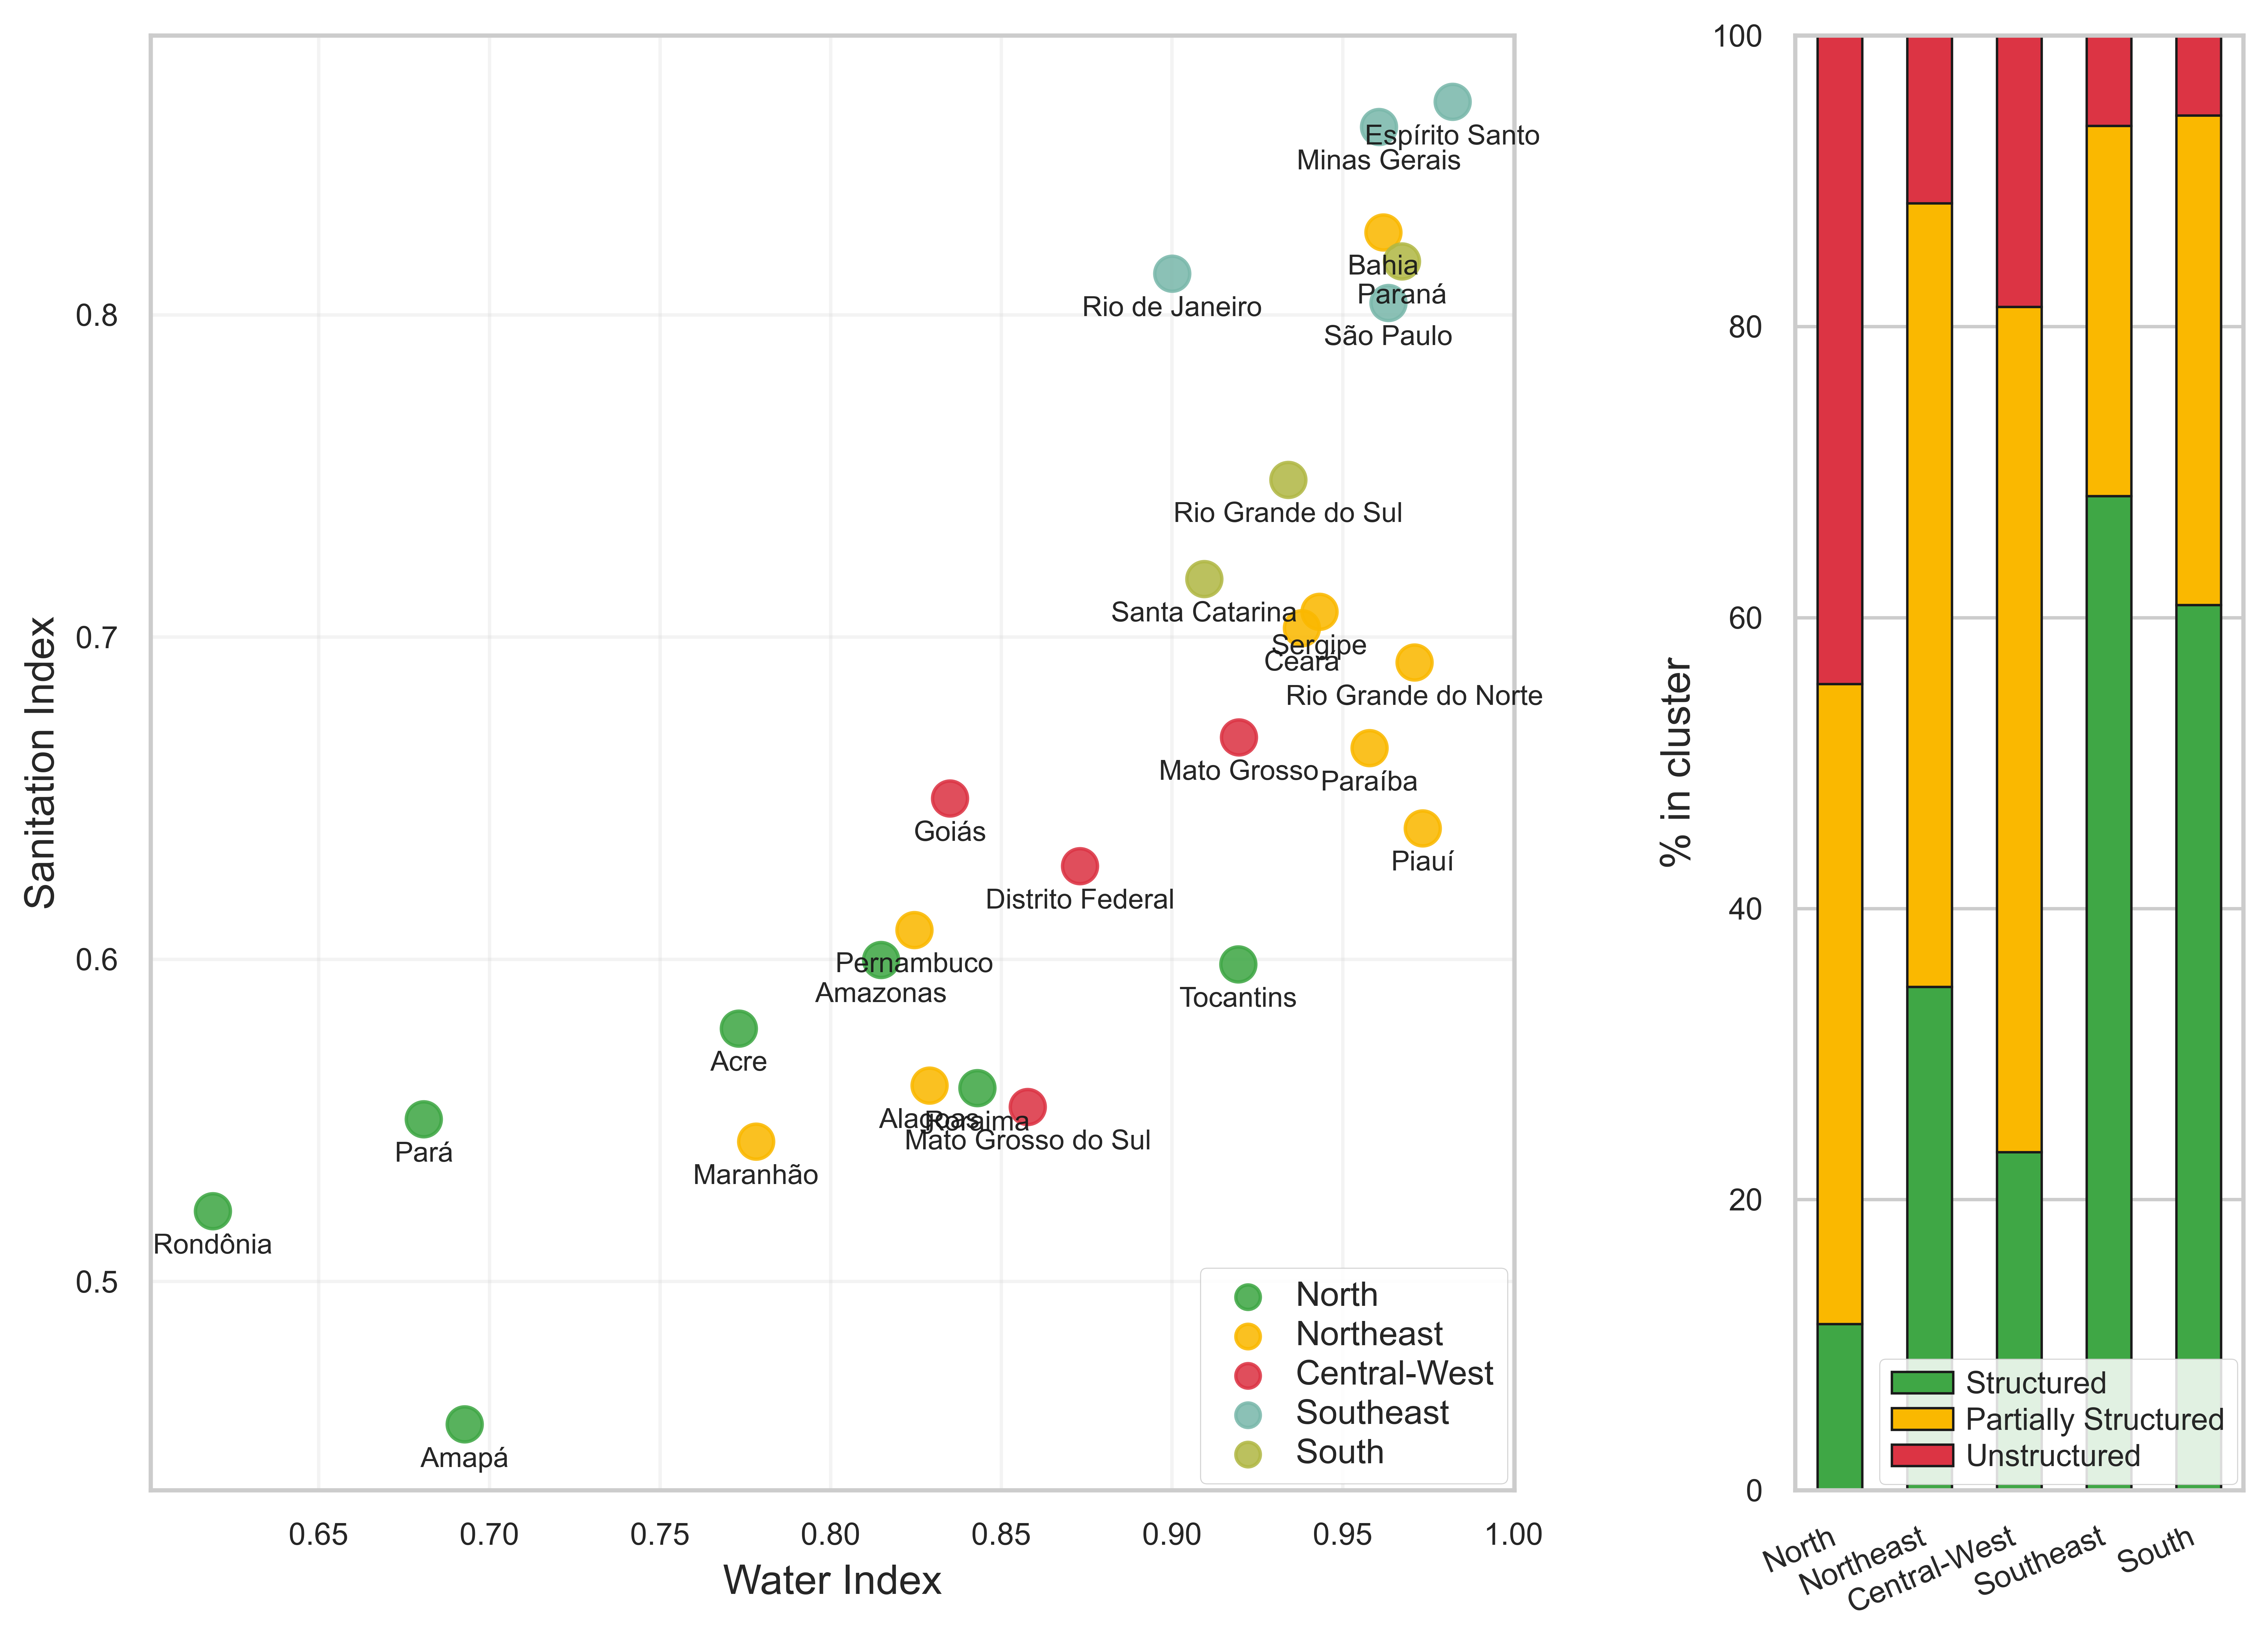

In [413]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---- Ensure consistent region names in English ----
region_map_to_en = {
    "North": "North",
    "Norte": "North",
    "Northeast": "Northeast",
    "Nordeste": "Northeast",
    "Southeast": "Southeast",
    "Sudeste": "Southeast",
    "South": "South",
    "Sul": "South",
    "Center-West": "Central-West",
    "Centro Oeste": "Central-West",
    "Centro-Oeste": "Central-West",
    "Central-West": "Central-West"
}
gdf["region"] = gdf["region"].replace(region_map_to_en)

import plotly.graph_objects as go

regions_order = ["North", "Northeast", "Central-West", "Southeast", "South"]

# Paleta de cores das regiões para o scatter, aproximada das cores dos clusters
region_palette = {
    "North": "#3fa745",         # Structured (verde) 
    "Northeast": "#fab800",     # Partially Structured (amarelo)
    "Central-West": "#dc3444",  # Unstructured (vermelho)
    "Southeast": "#7ab8ab",     # similar ao azul claro do boxplot original
    "South": "#b1b846",         # um tom verde-amarelado não usado ainda
}

# Cores dos clusters (barplot)
colors_cb = ["#3fa745", "#fab800", "#dc3444"]
cluster_label_map = {
    "0.0": "Structured",
    "1.0": "Partially Structured",
    "2.0": "Unstructured",
    0.0: "Structured",
    1.0: "Partially Structured",
    2.0: "Unstructured",
    0: "Structured",
    1: "Partially Structured",
    2: "Unstructured",
}

# ---- Data preparation ----
sankey_df = gdf.dropna(subset=["region", "cluster"]).copy()
sankey_df["cluster"] = sankey_df["cluster"].astype(str)
sankey_df["region"] = sankey_df["region"].astype(str)
sankey_df["region"] = sankey_df["region"].replace(region_map_to_en)

regions = [r for r in regions_order if r in sankey_df["region"].unique()]
clusters = sorted(sankey_df["cluster"].unique(), key=lambda x: int(float(x)) if x.replace('.', '', 1).isdigit() else x)
region_to_idx = {r: i for i, r in enumerate(regions)}
cluster_to_idx = {c: i + len(regions) for i, c in enumerate(clusters)}
counts = sankey_df.groupby(["region", "cluster"]).size().reset_index(name="count")
counts = counts[counts["count"] > 0]
sources = counts["region"].map(region_to_idx).tolist()
targets = counts["cluster"].map(cluster_to_idx).tolist()
values = counts["count"].tolist()
labels = regions + [f"Cluster {c}" for c in clusters]

# (B) Scatter by state
states_df = gdf.groupby(["CD_UF", "NM_UF", "region"], as_index=False)[["wtr_idx", "sanit_idx"]].mean()
states_df["region"] = states_df["region"].replace(region_map_to_en)

# (C) Bar plot: cluster prevalence by region
gdf["region"] = gdf["region"].replace(region_map_to_en)
ctab = gdf.groupby(["region", "cluster"]).size().unstack(fill_value=0)
ctab = ctab.reindex(regions_order)
ctab_perc = ctab.div(ctab.sum(axis=1), axis=0) * 100

#---------- PLots ----------
fig = plt.figure(figsize=(11, 7.5), dpi=780)

# Aumentar o espaçamento entre os plots aumentando wspace
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 2.3], width_ratios=[1.55, 1.59, 1.3])
plt.subplots_adjust(hspace=0.25, wspace=0.55, top=0.90)  # wspace estava 0.32, aumente para 0.55

# (b) Scatter plot: usar cores da paleta dos clusters nas regiões e sem borda nos pontos
ax1 = fig.add_subplot(gs[:, :2])
for r in regions_order:
    df = states_df[states_df["region"] == r]
    if df.empty:
        continue
    ax1.scatter(
        df["wtr_idx"],
        df["sanit_idx"],
        s=105,
        label=r,
        color=region_palette[r],
        edgecolor=None,
        alpha=0.87,
        zorder=2
    )
# -- Ajuste: fonte menor e texto à direita dos pontos (~dx)
for i, row in states_df.iterrows():
    if row["region"] not in region_palette: continue
    ax1.text(
        row["wtr_idx"] ,  # desloca para direita
        row["sanit_idx"] - 0.007,
        row["NM_UF"],
        fontsize=8.2,            # fonte menor
        ha="center",               # alinhamento à direita do ponto (left)
        va="top",
        color="k",
        alpha=0.95,
        zorder=3
    )
ax1.set_xlabel("Water Index", fontsize=12)
ax1.set_ylabel("Sanitation Index", fontsize=12)
ax1.grid(True, alpha=0.22)
ax1.tick_params(axis='both', which='major', labelsize=9)
legend1 = ax1.legend(fontsize=10, title_fontsize=8, loc="lower right", markerscale=0.7, handletextpad=0.4, borderaxespad=0.2, labelspacing=0.25)
legend1.get_frame().set_linewidth(0.3)
legend1.get_frame().set_alpha(0.85)

# (c) Bar plot: clusters by region, mesma paleta para clusters
ax2 = fig.add_subplot(gs[:, 2])
cluster_colors = {i: colors_cb[i % len(colors_cb)] for i in range(ctab_perc.shape[1])}
ctab_perc.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[cluster_colors[i] for i in range(ctab_perc.shape[1])],
    edgecolor="k",
    linewidth=0.7,
)
ax2.set_ylabel("% in cluster", fontsize=12)
ax2.set_xlabel("")
# -- Legenda do barplot agora embaixo
legend2 = ax2.legend(
    [cluster_label_map.get(str(c)) for c in ctab_perc.columns],
    # title="Cluster",
    fontsize=9, title_fontsize=8,
    loc="lower right", 
    borderaxespad=0.2, handletextpad=0.4, labelspacing=0.25, ncol=1
)
legend2.get_frame().set_linewidth(0.3)
legend2.get_frame().set_alpha(0.85)
ax2.set_ylim(0, 100)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=23, ha='right')
ax2.tick_params(axis='both', which='major', labelsize=9)

plt.show()


In [414]:
import plotly.graph_objects as go

# --------- Sankey: proporção por região -> cluster ---------

# Criar coluna 'region' em gdf, igual ao que foi feito em grouped anteriormente
if "region" not in gdf.columns:
    states_to_region = {uf: uf_to_region.get(str(uf), None) for uf in gdf["CD_UF"]}
    gdf["region"] = gdf["CD_UF"].astype(str).map(states_to_region)

# Prosseguir normalmente
sankey_df = gdf.dropna(subset=["region", "cluster"]).copy()
sankey_df["cluster"] = sankey_df["cluster"].astype(str)
sankey_df["region"] = sankey_df["region"].astype(str)

regions = sorted(sankey_df["region"].unique())
clusters = sorted(sankey_df["cluster"].unique())

region_to_idx = {r: i for i, r in enumerate(regions)}
cluster_to_idx = {c: i + len(regions) for i, c in enumerate(clusters)}

counts = sankey_df.groupby(["region", "cluster"]).size().reset_index(name="count")
counts = counts[counts["count"] > 0]

sources = counts["region"].map(region_to_idx).tolist()
targets = counts["cluster"].map(cluster_to_idx).tolist()
values = counts["count"].tolist()

# Paleta para clusters
cluster_palette = {
    "0.0": "#3fa745",
    "1.0": "#fab800",
    "2.0": "#dc3444"
}
cluster_colors_list = ["#3fa745", "#fab800", "#dc3444"]
cluster_colors = [cluster_palette.get(str(c), cluster_colors_list[i % len(cluster_colors_list)]) for i, c in enumerate(clusters)]

# Função para aplicar alpha/transparência em cores hex
def hex_to_rgba(hex_color, alpha=0.28):
    hex_color = hex_color.lstrip("#")
    lv = len(hex_color)
    rgb = tuple(int(hex_color[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
    return f"rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha})"

# Cores das linhas (com transparência)
link_colors = []
for _, row in counts.iterrows():
    c = str(row["cluster"])
    base = cluster_palette.get(c, "#888888")
    link_colors.append(hex_to_rgba(base, 0.28))

labels = regions + [cluster_label_map.get(str(c), f"Cluster {c}") for c in clusters]

# node cor: regiões cinza claro; clusters nas cores padrão
# outline: regiões cinza escuro e bem fino; clusters normal/preto
node_colors = ["#cccccc"]*len(regions) + cluster_colors
node_line_colors = ["#999999"]*len(regions) + ["black"]*len(clusters)
node_line_widths = [0.8]*len(regions) + [0.6]*len(clusters)  # mas Plotly só aceita um valor, então só regiões afeta outline

# Atenção: thickness é global no Sankey Plotly, afeta todos os nodes!
# Então, para "nós finos" só é possível deixar todos finos ou grossos.
# Como alternativa, deixar todos finos (thickness baixo) e compensar com cor/borda cinza para as regiões.

fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 20,
        thickness = 10,  # fino para todos
        line = dict(color=node_line_colors, width=0.8),  # outline: regiões cinza, clusters preto; width fino
        label = labels,
        color = node_colors
    ),
    link = dict(
        source = sources,
        target = targets,
        value = values,
        color = link_colors  # Transparência nas cores dos links do cluster
    )
)])

fig.update_layout(font_size=40, height=1350, width=3650)
fig.show()


In [5]:
gdf['depriv_idx'].sort_values()

5414   -10.679565772108035
9961    -8.904604335086541
7710    -8.425454512913397
2899    -8.425372564968242
2683    -7.897814068768687
               ...        
9386    23.754707008030969
7533    24.700476820923029
3436    25.449775486962679
7086    25.503590426729687
156     26.979506308228991
Name: depriv_idx, Length: 11605, dtype: float64

In [6]:
colors = ['#3fa745', '#ecb102', '#dc3444']

In [7]:
dict_vars = {
    'population': ['log_population'],
    'demographics': [['age_idx'], ['literate'], ['depriv_idx']],
    'race': ['race_wht', 'race_brn', 'race_blk'], #'race_ylw', 'race_ind', 'race_unk'],
    'pollutants': [['CO'], ['O3'], ['SO2'], ['NO2']],
    'topography': [['slope_10', 'slope_20', 'slope_30', 'slope_30p'], ['hand_0_3', 'hand_3_6', 'hand_6p']],
    'health': ['log_prim_hosp', 'log_inp_hosp'],
    'services': [['waste_coll'], ['log_est_dens']],
}

In [8]:
def melt_long(df, cols, cluster_col, var_label, val_label):
    return df.dropna(subset=cols + [cluster_col]).melt(
        id_vars=cluster_col,
        value_vars=cols,
        var_name=var_label,
        value_name=val_label
    )

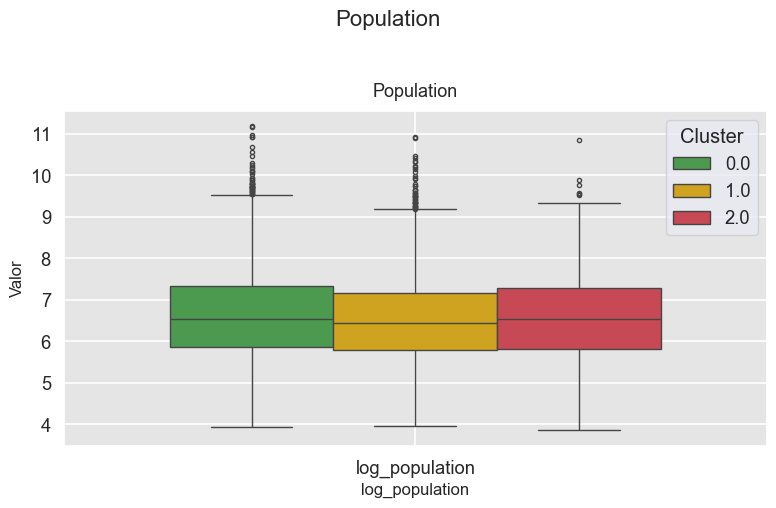

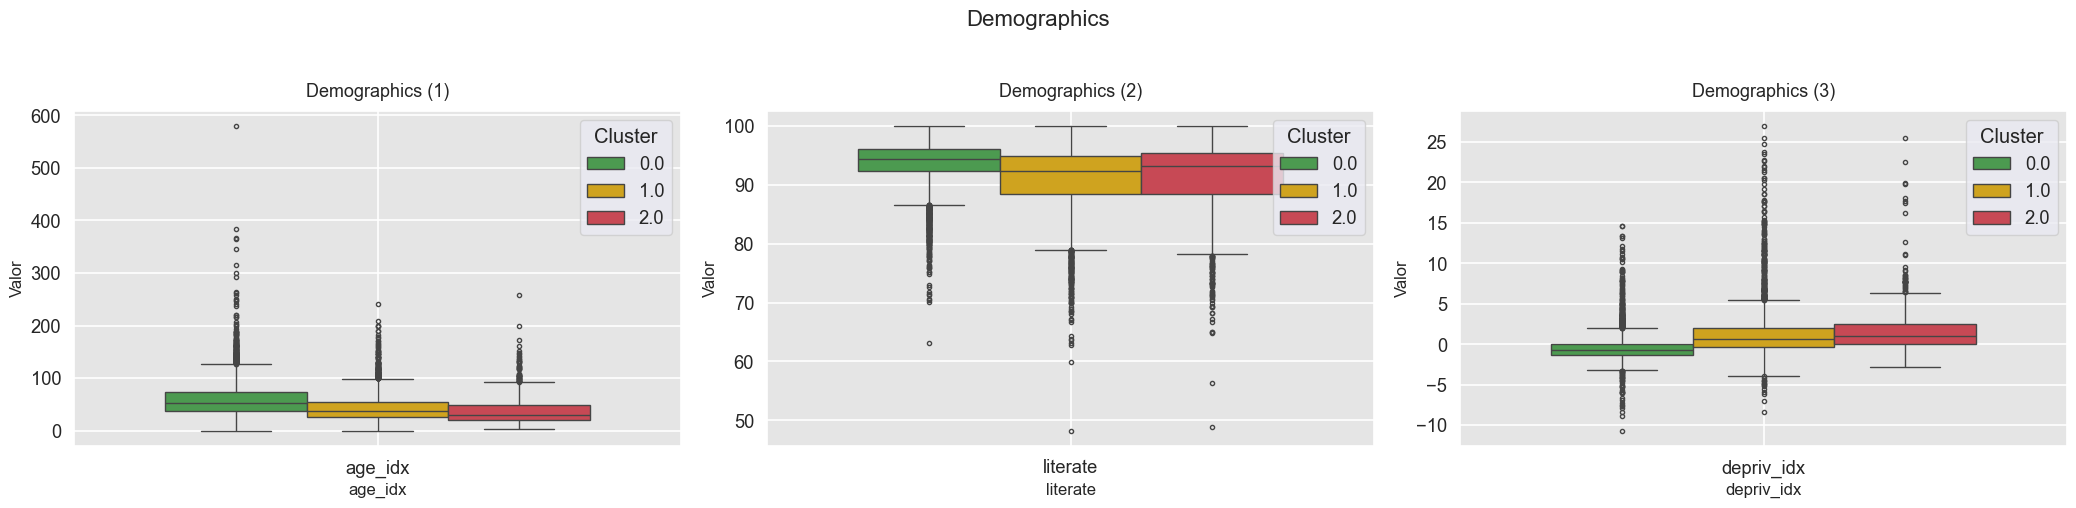

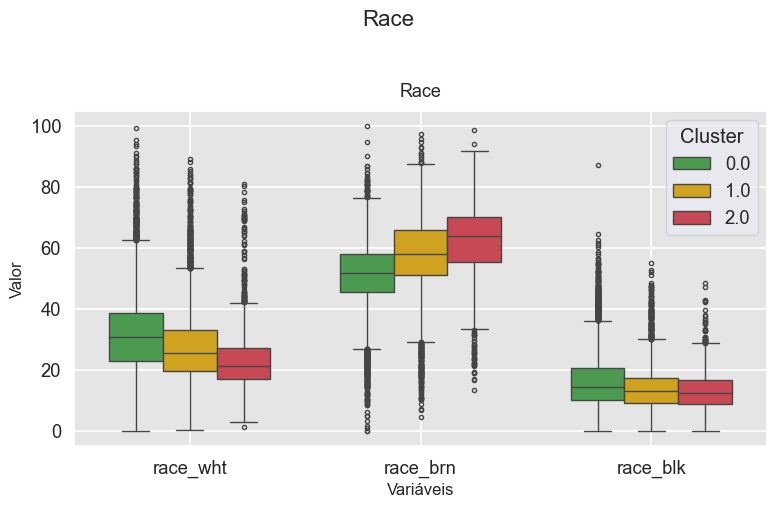

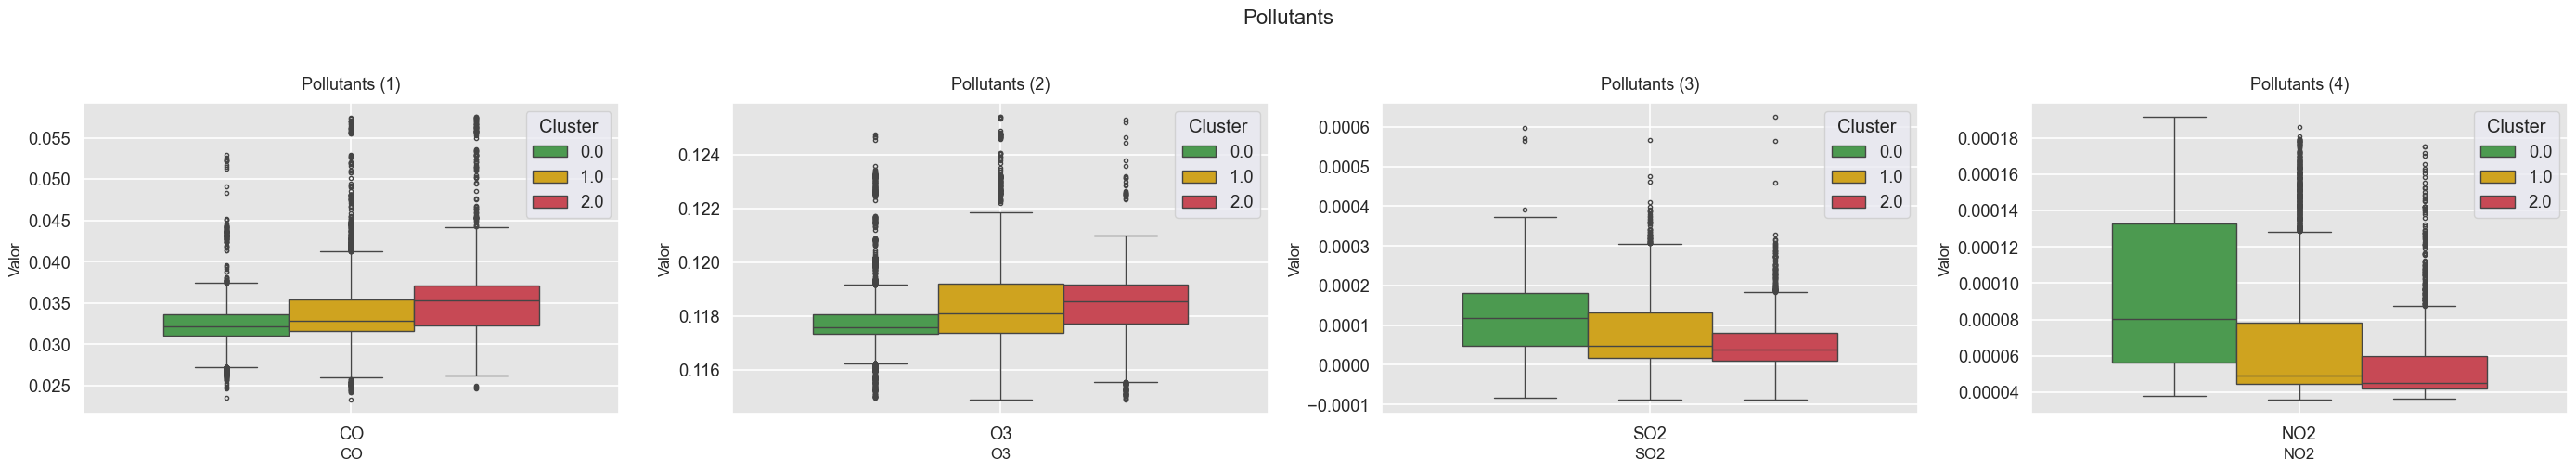

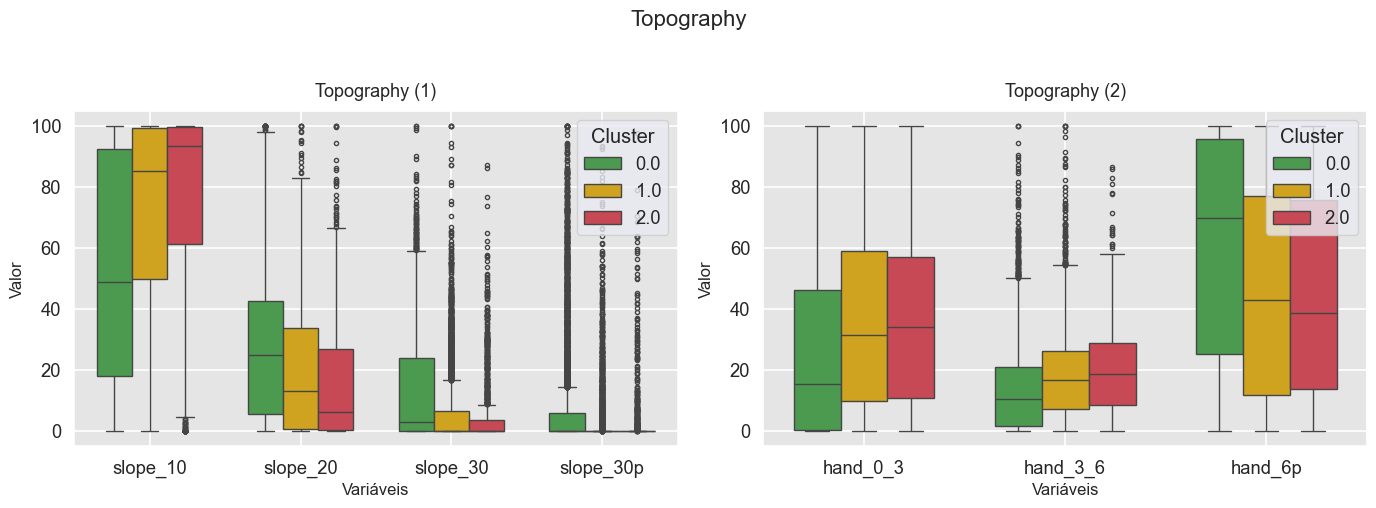

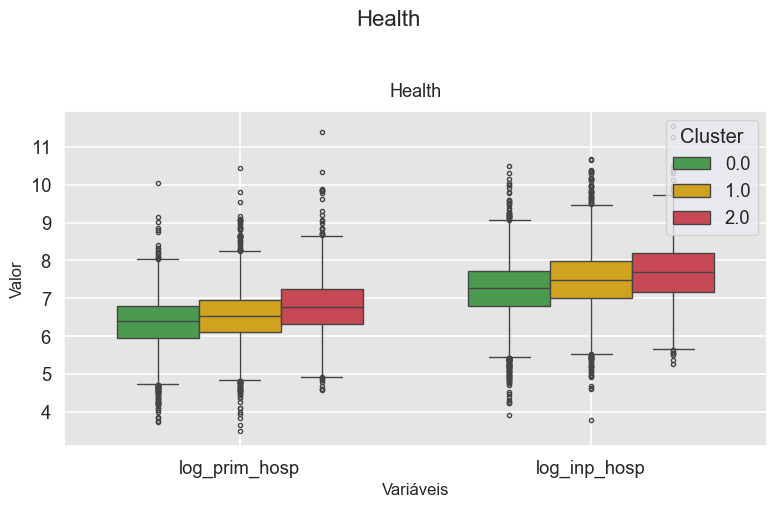

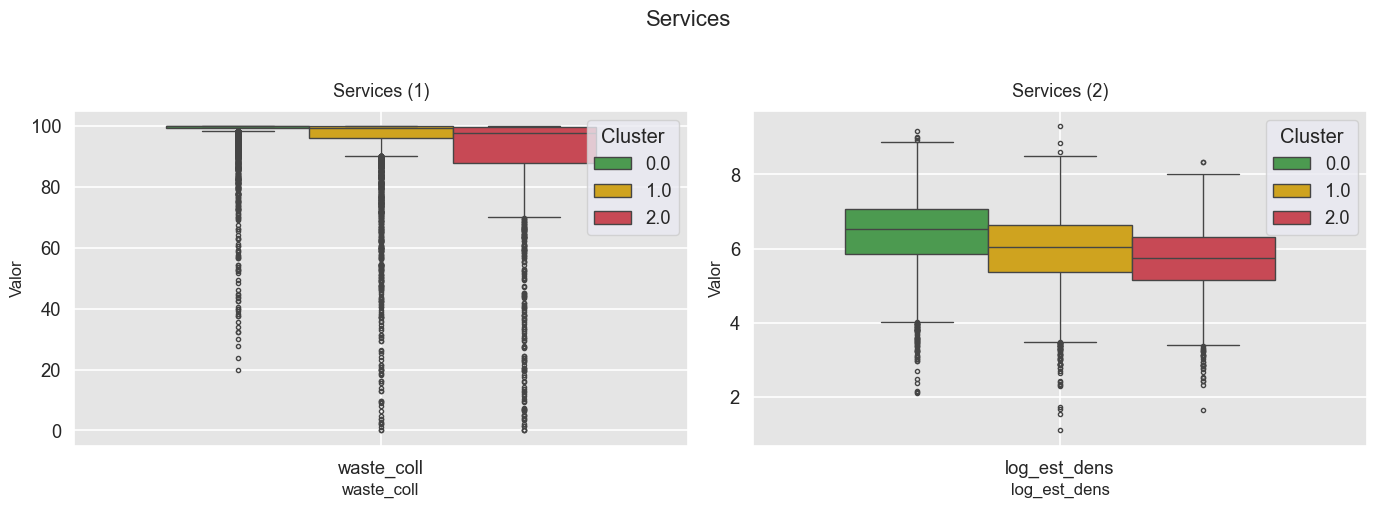

In [9]:
# --------- Variáveis ---------
cluster_col = 'cluster'

# helper para lidar com múltiplos arrays dentro de cada grupo no dict_vars
def get_var_groups(varset):
    if all(isinstance(v, list) for v in varset):
        return varset
    return [varset]

# Cada plot deve ter sua própria escala no y (sharey=False)
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.2)

for group, varset in dict_vars.items():
    # Cada linha: um grupo de variáveis
    var_groups = get_var_groups(varset)
    n_plots = len(var_groups)
    if n_plots == 1:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5), sharey=False)
        axes = [ax]
    else:
        fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5), sharey=False)  # sharey=False garante escalas independentes
        if n_plots == 2:
            axes = list(axes)
        else:
            axes = axes.flat if hasattr(axes, "flat") else axes

    for idx, cols in enumerate(var_groups):
        df_long = melt_long(gdf, cols, cluster_col, 'Variável', 'Valor')
        ax = axes[idx] if n_plots > 1 else axes[0]

        sns.boxplot(
            data=df_long,
            x='Variável',
            y='Valor',
            hue='cluster',
            palette=colors,
            width=0.7,
            fliersize=3,
            linewidth=1,
            ax=ax,
            showfliers=True
        )
        ax.set_xlabel("Variáveis" if len(cols) > 1 else cols[0], fontsize=12)
        ax.set_ylabel("Valor", fontsize=12)
        ax.set_title(f"{group.capitalize().replace('_', ' ')}" + (f" ({idx+1})" if n_plots > 1 else ""), fontsize=13, pad=10)
        ax.legend(title="Cluster", loc='upper right', frameon=True)
        ax.set_facecolor('#E5E5E5')
        ax.grid(True, color='white', linewidth=1.2)
    
    fig.suptitle(group.capitalize().replace('_', ' '), fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


In [19]:
dict_vars = {
    'global': [
        ['log_population'],
        ['age_idx'], ['literate'], ['depriv_idx'],
        ['race_wht', 'race_brn', 'race_blk'], #'race_ylw', 'race_ind', 'race_unk'],
        ['CO'], ['O3'], ['SO2'], ['NO2'],
        ['slope_10', 'slope_20', 'slope_30', 'slope_30p'], ['hand_0_3', 'hand_3_6', 'hand_6p'],
        ['log_prim_hosp', 'log_inp_hosp'],
        ['waste_coll'], ['log_est_dens']
    ],
    # 'population': ['log_population'],
    # 'demographics': [['age_idx'], ['literate'], ['depriv_idx']],
    # 'race': ['race_wht', 'race_brn', 'race_blk'], #'race_ylw', 'race_ind', 'race_unk'],
    # 'pollutants': [['CO'], ['O3'], ['SO2'], ['NO2']],
    # 'topography': [['slope_10', 'slope_20', 'slope_30', 'slope_30p'], ['hand_0_3', 'hand_3_6', 'hand_6p']],
    # 'health': ['log_prim_hosp', 'log_inp_hosp'],
    # 'services': [['waste_coll'], ['log_est_dens']],
}

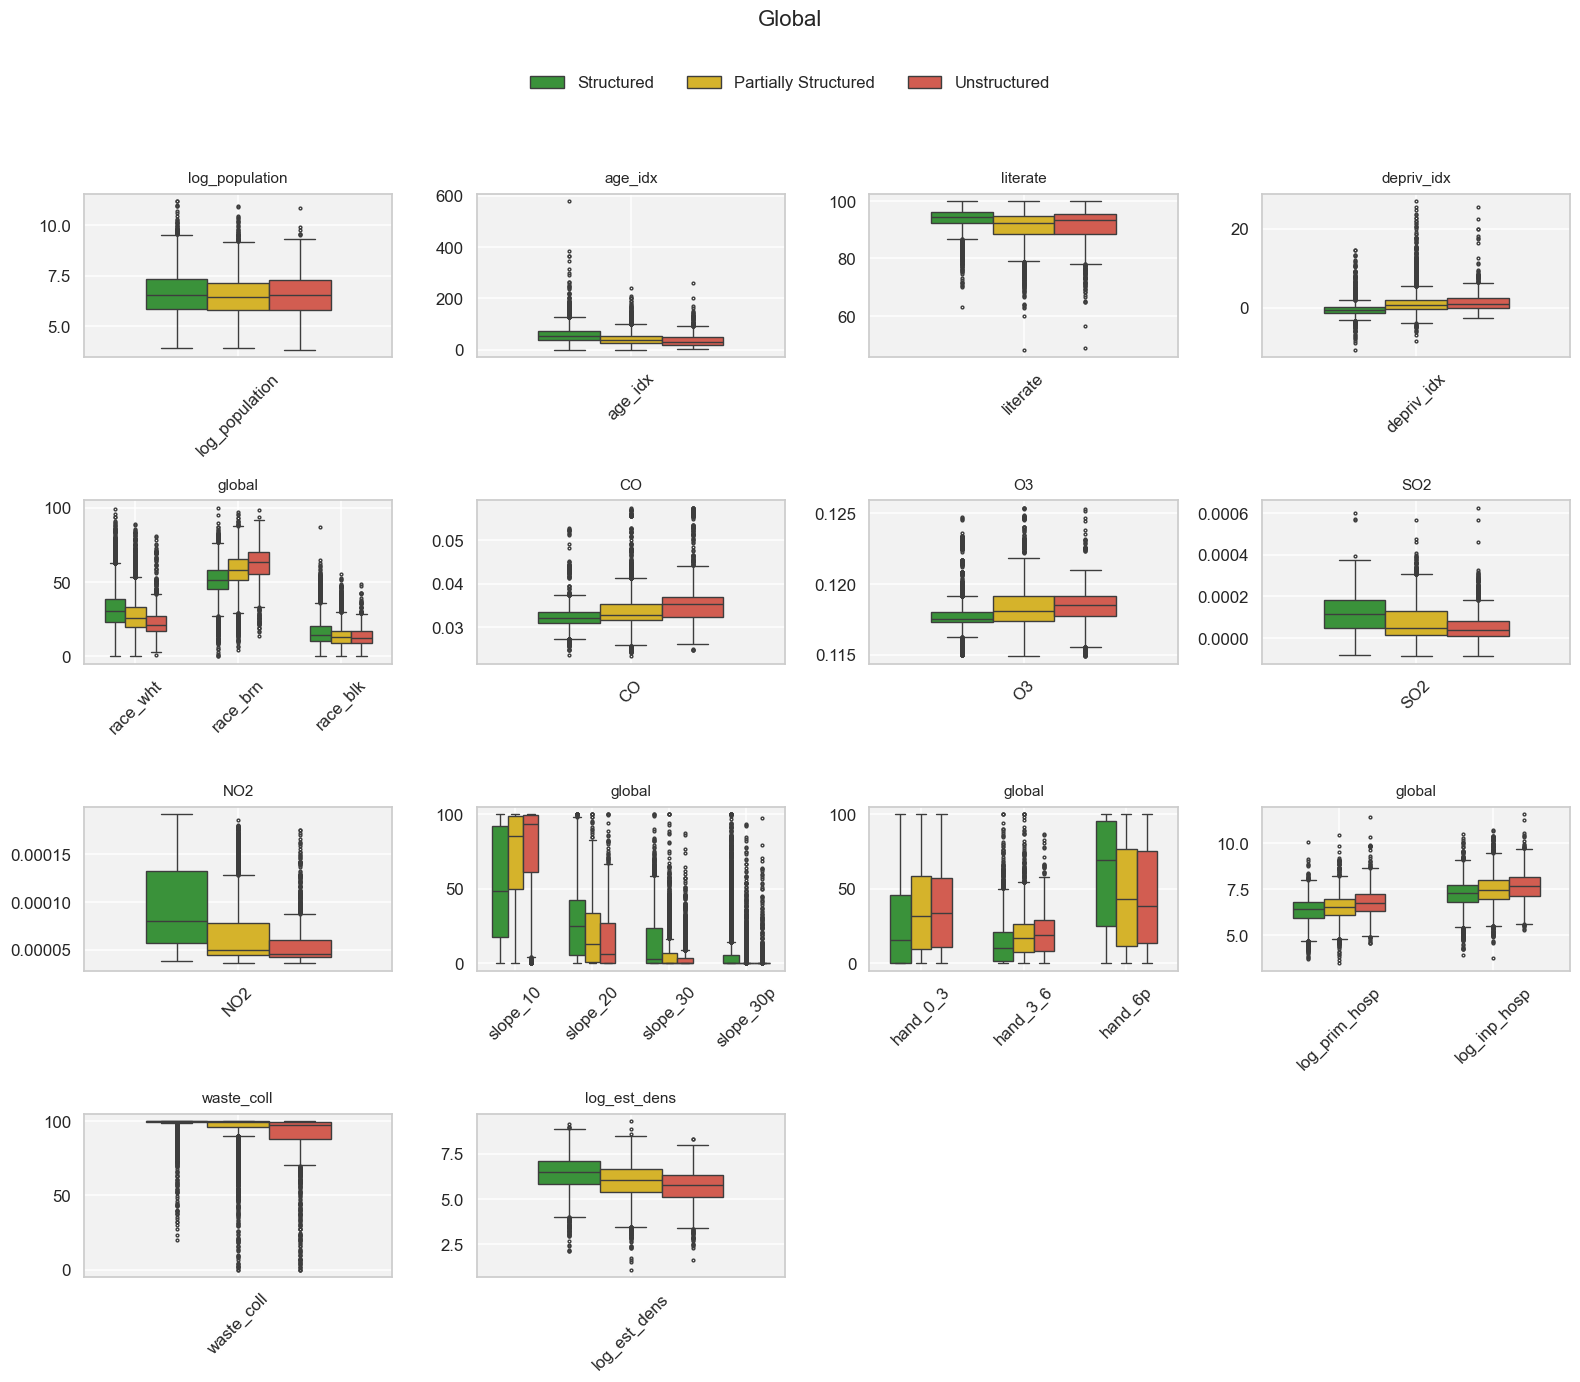

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)

cluster_col = "cluster"

# paleta consistente
palette = {
    0: "#2ca02c",   # Structured
    1: "#f1c40f",   # Partially Structured
    2: "#e74c3c"    # Unstructured
}

def flatten_groups(varset):
    """Converte estrutura mista (list ou list de lists) em lista de grupos."""
    if all(isinstance(v, list) for v in varset):
        return varset
    return [varset]

def melt_vars(df, vars, cluster_col="cluster"):
    """Transforma para formato longo para seaborn."""
    return df.melt(
        id_vars=cluster_col,
        value_vars=vars,
        var_name="Variable",
        value_name="Value"
    ).dropna()

# LOOP PRINCIPAL
for group_name, var_group in dict_vars.items():

    groups = flatten_groups(var_group)
    n_vars = len(groups)

    # grid de subplots como no exemplo Nature: 4 colunas
    n_cols = 4
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3.2 * n_rows),
        sharey=False
    )

    # >>> Correção robusta <<<
    axes = np.ravel(axes).tolist()

    for i, cols in enumerate(groups):
        ax = axes[i]
        df_long = melt_vars(gdf, cols, cluster_col)

        sns.boxplot(
            data=df_long,
            x="Variable",
            y="Value",
            hue=cluster_col,
            palette=palette,
            ax=ax,
            linewidth=1,
            fliersize=2,
            width=0.6
        )

        ax.set_title(cols[0] if len(cols)==1 else group_name, fontsize=11, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_facecolor("#F2F2F2")
        ax.grid(True, color="white", linewidth=1.1)

        ax.legend([], [], frameon=False)
        ax.tick_params(axis='x', rotation=45)

    # Subplots sobrando → desligar
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # LEGENDA ÚNICA
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, ["Structured", "Partially Structured", "Unstructured"],
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.5, 1.04)
    )

    fig.suptitle(group_name.capitalize(), fontsize=16, y=1.08)
    plt.tight_layout()
    plt.show()


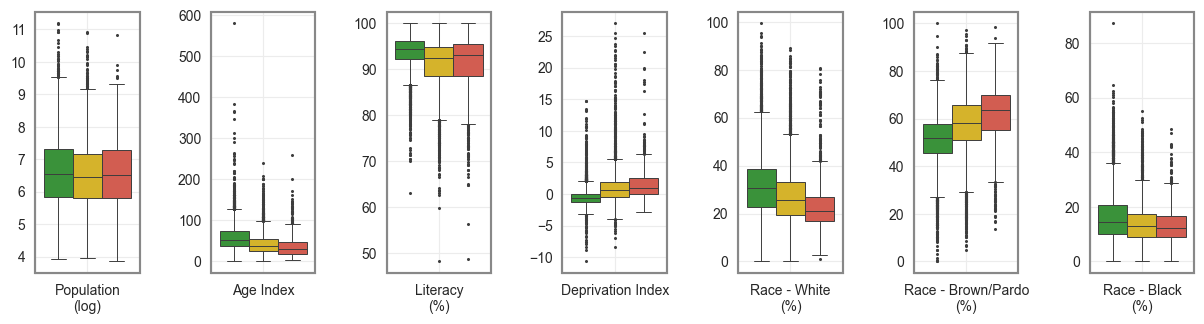

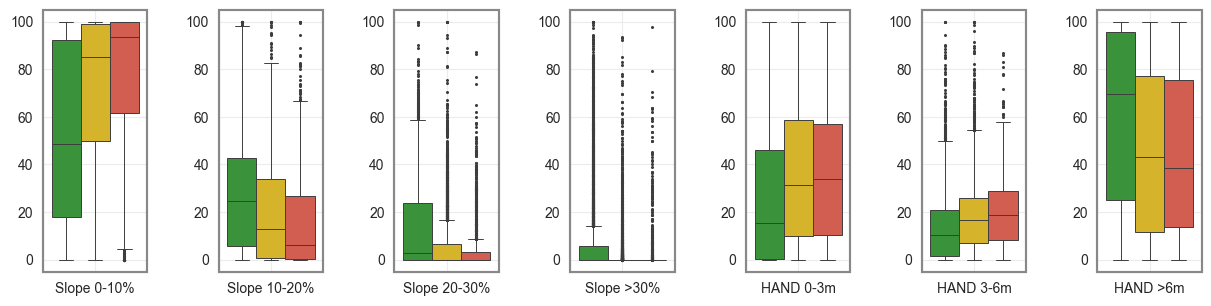

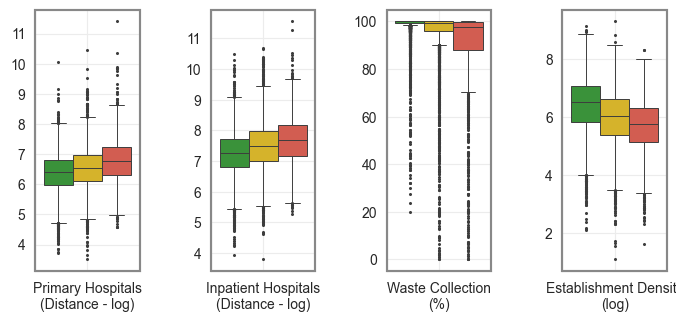

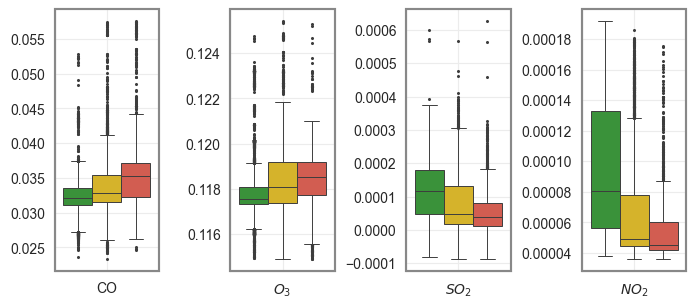

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Readable variable names in English
pretty_names = {
    "age_idx": "Age Index",
    "literate": "Literacy\n(%)",
    "depriv_idx": "Deprivation Index",
    "race_wht": "Race - White\n(%)",
    "race_brn": "Race - Brown/Pardo\n(%)",
    "race_blk": "Race - Black\n(%)",
    "CO": "CO",
    "O3": r"$O_3$",
    "SO2": r"$SO_2$",
    "NO2": r"$NO_2$",
    "slope_10": "Slope 0-10%",
    "slope_20": "Slope 10-20%",
    "slope_30": "Slope 20-30%",
    "slope_30p": "Slope >30%",
    "hand_0_3": "HAND 0-3m",
    "hand_3_6": "HAND 3-6m",
    "hand_6p": "HAND >6m",
    "log_prim_hosp": "Primary Hospitals\n(Distance - log)",
    "log_inp_hosp": "Inpatient Hospitals\n(Distance - log)",
    "waste_coll": "Waste Collection\n(%)",
    "log_est_dens": "Establishment Density\n(log)",
    "log_population": "Population\n(log)"
}
# Themes in English
themes = {
    "Demographics": ["log_population", "age_idx", "literate", "depriv_idx", "race_wht", "race_brn", "race_blk"],
    "Topography": ["slope_10", "slope_20", "slope_30", "slope_30p", "hand_0_3", "hand_3_6", "hand_6p"],
    "Infrastructure": ["log_prim_hosp", "log_inp_hosp", "waste_coll", "log_est_dens"],
    "Pollutants":    ["CO", "O3", "SO2", "NO2"]
    # "Race": ["race_wht", "race_brn", "race_blk"],
    # "Slope":   ["slope_10", "slope_20", "slope_30", "slope_30p"],
    # "HAND": ["hand_0_3", "hand_3_6", "hand_6p"],
}

palette = {
    0: "#2ca02c",   # Structured
    1: "#f1c40f",   # Partially Structured
    2: "#e74c3c"    # Unstructured
}

cluster_col = "cluster" if "cluster" in gdf.columns else list(gdf.columns)[-1]

# melt helper
def melt_vars(df, varlist, cluster_col):
    df_long = (
        df[varlist + [cluster_col]]
        .melt(id_vars=cluster_col, value_vars=varlist, var_name="Variable", value_name="Value")
    )
    df_long["Variable"] = df_long["Variable"].map(pretty_names)
    return df_long

# Proportion per plot (same as before)
box_width = 1.1
box_height = 3.4
h_gap = 0.75
v_gap = 0.7

# REMOVED legend_labels and all legend usage

for theme, vars_ in themes.items():
    n_vars = len(vars_)
    fig_width = n_vars * box_width + (n_vars - 1) * h_gap
    fig_height = box_height

    fig, axes = plt.subplots(1, n_vars, figsize=(fig_width, fig_height), sharey=False)
    fig.patch.set_facecolor('white')

    # Ensure axes is always 1D np.ndarray
    if n_vars == 1:
        axes = np.array([axes])

    for j, var in enumerate(vars_):
        ax = axes[j]
        df_long = melt_vars(gdf, [var], cluster_col)
        cluster_order = sorted(gdf[cluster_col].unique())
        pal = [palette.get(k, f"C{k}") for k in cluster_order]
        sns.boxplot(
            data=df_long,
            x="Variable",
            y="Value",
            hue=cluster_col,
            palette=pal,
            ax=ax,
            linewidth=0.7,
            fliersize=1.2,
            width=0.01,
        )
        # Always remove the legend for each subplot (remove legend of colors)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        ax.set_title("")  # remove title
        ax.set_xlabel(pretty_names.get(var, var), fontsize=10, labelpad=4)
        ax.set_xticklabels([])  # no ticklabels since only one var
        ax.set_ylabel("", fontsize=12, labelpad=0)
        ax.tick_params(axis="y", labelsize=10, pad=1)
        ax.set_facecolor("white")
        ax.grid(True, color="#ececec", linewidth=0.85)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color("#bbbbbb")
            ax.spines[spine].set_linewidth(0.8)
        ax.tick_params(axis="x", which="both", length=0)
        ax.margins(x=0.10)
        # Adiciona borda retangular sutil ao redor de cada plot apenas
        from matplotlib.patches import Rectangle
        rect = Rectangle(
            (0, 0),
            1, 1,
            transform=ax.transAxes,
            fill=False,
            edgecolor='#888888',
            linewidth=1.55,
            zorder=1000,
            clip_on=False
        )
        ax.add_patch(rect)

    # Hide unused axes if any (shouldn't apply here, but for robustness)
    if len(axes) > n_vars:
        for ax in axes[n_vars:]:
            ax.axis('off')

    # REMOVE the unique legend block here (do not add fig.legend)
    # (Remove the code getting handles/labels and calling fig.legend)
    # plt.subplots_adjust(right=0.95)

    plt.subplots_adjust(
        wspace=h_gap/box_width,
        top=1,
        left=0.05,
        bottom=0.23,
        right=1
    )

    plt.show()
